In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import binom, poisson
from math import comb

# Part I

Verify that the table is a valid PMF, state the support, and distinguish the random variable 
x from an observed value X.

In [5]:
x = np.array([0,1,2,3,4])
p = np.array([0.58, 0.26, 0.10, 0.04, 0.02])

print(f"Sum of probabilities equals 1: {np.isclose(p.sum(), 1)}")
print(f"All probabilities are non-negative: {(p >= 0).all()}")

Sum of probabilities equals 1: True
All probabilities are non-negative: True


In [6]:
df = pd.DataFrame({
  "x" : x,
  "p_X": p
})

#CDF
df["F_X"] = df["p_X"].cumsum()
display(df)

print(
  f"P (X = 2): {p[x == 2].sum()}\n"
  f"P (X <= 1): {p[x <= 1].sum()}\n"
  f"P (1 < X <= 3): {p[(x > 1) & (x <= 3)].sum()}"
  )

,x,p_X,F_X
0,0,0.58,0.58
1,1,0.26,0.84
2,2,0.10,0.94
3,3,0.04,0.98
4,4,0.02,1.00


P (X = 2): 0.1
P (X <= 1): 0.84
P (1 < X <= 3): 0.14


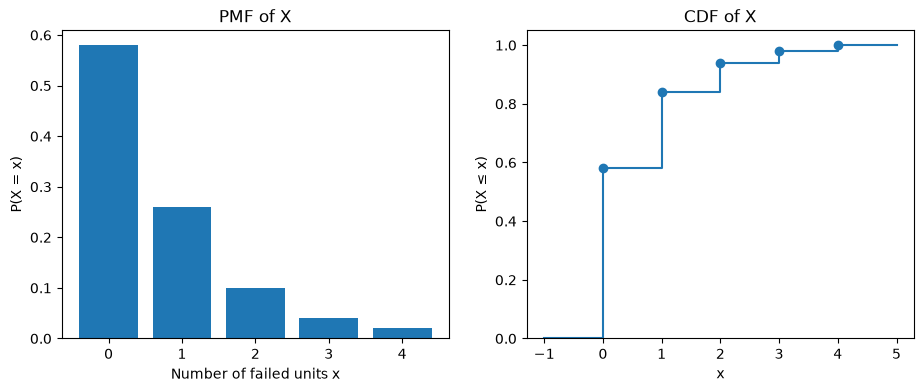

In [7]:
x = np.array([0, 1, 2, 3, 4])
p = np.array([0.58, 0.26, 0.10, 0.04, 0.02])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.bar(x, p)
ax1.set(title="PMF of X", xlabel="Number of failed units x", ylabel="P(X = x)")

xs = np.r_[-1, x, 5]
Fs = np.r_[0, np.cumsum(p), 1]
ax2.step(xs, Fs, where="post")
ax2.scatter(x, np.cumsum(p), zorder=3)
ax2.set(title="CDF of X", xlabel="x", ylabel="P(X ≤ x)", ylim=(0, 1.05))
plt.show()

In the PMF, the bar height at x is the probability that exactly x units fail in a week. For example, the bar at 0 has height 0.58, so there's a 58% chance no unit fails.

In the CDF, the height at x is the probability that at most x units fail: 0.58, 0.84, 0.94, 0.98, 1.00. For example, F(1) = 0.84 means there's an 84% chance of one failure or fewer. The CDF stays flat between integers because X can't take values like 1.5, and the size of each jump equals the PMF bar at that point (the jump at 2 is 0.94 − 0.84 = 0.10).

In [8]:
E = np.sum(x * p)
Var = np.sum((x - E)**2 * p)
SD = np.sqrt(Var)
print(f"E[X] = {E:.4f}, Var(X) = {Var:.4f}, SD(X) = {SD:.4f}")

E[X] = 0.6600, Var(X) = 0.9044, SD(X) = 0.9510


#note for marty party , i just used AI for creating the graphs

# Part II Repeated-event count models
A project expects 30 deliveries. Each is modelled as late with probability 0.12 independently of the others. Let "B" be the number of late deliveries.

Justify B ~ Bin(30, 0.12). Identify the Bernoulli trial and discuss fixed n, constant p, independence, and one
realistic violation.

**a. Justifying the model**

This model only holds if:

- **Fixed $n$:** the project has exactly 30 deliveries, so the number of trials is known beforehand.
- **Constant $p$:** every delivery has the same 12% chance of being late.
- **Independence:** one delivery being late does not change the chance that another is late.

A realistic violation is independence. If several deliveries come from the same supplier, or go through the same port or the same bad weather, one late delivery makes the others more likely to be late too. The late deliveries then come in groups/chunks, and the real spread of $B$ would be larger than the binomial says.

In [9]:
n, p = 30, 0.12

p_b3 = binom.pmf(3, n, p)
p_b_le4 = binom.cdf(4, n, p)
p_b_ge5 = binom.sf(4, n, p)

print(f"P(B = 3)  = {p_b3:.4f}")
print(f"P(B <= 4) = {p_b_le4:.4f}")
print(f"P(B >= 5) = {p_b_ge5:.4f}")
print(f"P(B <= 4) + P(B >= 5) = {p_b_le4 + p_b_ge5:.4f}")

# same P(B = 3) but formula written out
manual = comb(n, 3) * p**3 * (1 - p)**(n - 3)
print(f"\nC(30, 3) = {comb(n, 3)}")
print(f"P(B = 3) by formula = {manual:.4f}")

P(B = 3)  = 0.2224
P(B <= 4) = 0.7118
P(B >= 5) = 0.2882
P(B <= 4) + P(B >= 5) = 1.0000

C(30, 3) = 4060
P(B = 3) by formula = 0.2224


**b. Probabilities**

- P(B = 3) = 0.2224, so about a 22% chance of exactly 3 late deliveries
- P(B ≤ 4) = 0.7118, so about a 71% chance of at most 4 late deliveries
- P(B ≥ 5) = 0.2882, so about a 29% chance of 5 or more late deliveries

The formula for exactly 3 late deliveries is:

P(B = 3) = C(30, 3) × 0.12³ × 0.88²⁷

C(30, 3) = 4060 is the number of ways to choose which 3 of the 30 deliveries are the late ones. Each of those choices has the same probability, 0.12³ × 0.88²⁷ (3 late, 27 on time), so I multiply the two. The result matches the SciPy value.

For the upper tail, `binom.sf(k, n, p)` gives P(B > k), not P(B ≥ k). B only takes whole numbers, so B ≥ 5 is the same as B > 4, which means I use `sf(4)`. Using `sf(5)` would give P(B ≥ 6) instead. As a check, 0.7118 + 0.2882 = 1.

**c. Mean and standard deviation**

In [10]:
mean_b = n * p
sd_b = np.sqrt(n * p * (1 - p))

print(f"E[B] = {mean_b:.2f}")
print(f"SD(B) = {sd_b:.4f}")
print(f"SciPy check: {binom.mean(n, p):.2f}, {binom.std(n, p):.4f}")

E[B] = 3.60
SD(B) = 1.7799
SciPy check: 3.60, 1.7799


**c. Mean and standard deviation**

- Mean = n × p = 30 × 0.12 = 3.6
- SD = √(n × p × (1 − p)) = √(30 × 0.12 × 0.88) = 1.78

On average, 3.6 of the 30 deliveries are late. The standard deviation of about 1.8 shows how far the count usually is from that average, so 2 to 5 late deliveries would not be surprising. This fits with P(B ≥ 5) being 29%.